In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import itertools

In [4]:
#Loads the MNIST dataset, downsamples the images to 14x14
transform = transforms.Compose([
    transforms.Resize((14, 14)), #resizes to 14x14
    transforms.ToTensor(),
])

#Load MNIST dataset and apply transformations
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Using downloaded and verified file: ./data/MNIST/raw/train-images-idx3-ubyte.gz
Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw




KeyboardInterrupt: 

In [3]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

#Display a batch of images
def show_images(train_dataset, cols, rows):
  figure = plt.figure(figsize=(8, 8))

  for i in range(1, cols * rows + 1):
      sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
      img, label = train_dataset[sample_idx]
      figure.add_subplot(rows, cols, i)
      plt.title(labels_map[label])
      plt.axis("off")
      plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

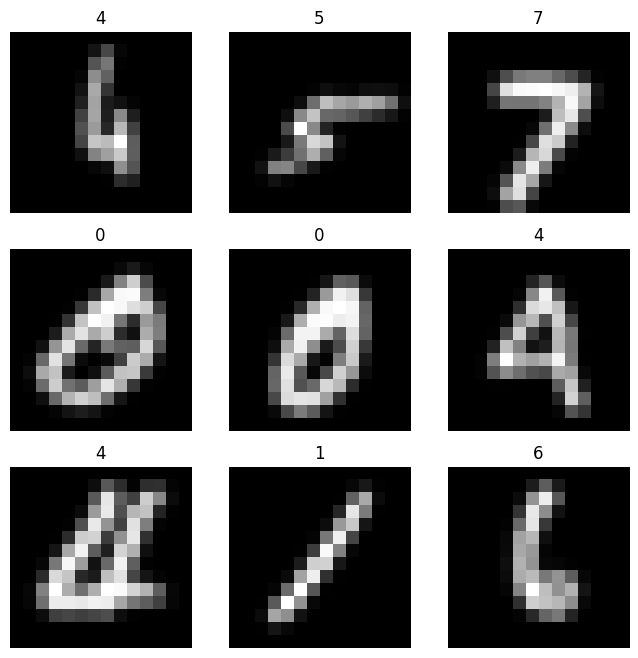

In [4]:
show_images(train_dataset, 3, 3)

All my architectures for each step

In [ ]:
#architecture from Part 2(reference)
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

#This sublayer is implemented by CustomLayer and simulates a chip core containing up to 128 units. To handle 256 units it splits its input into 2 128-element vectors and uses multiple learnable weight matrices to simulate negative weights. It outputs a 128-element weighted sum vector passed through an activation function
class SubLayer(nn.Module):
  def __init__(self):
    super(SubLayer, self).__init__()

    #create 2 128x128 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 128))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 128)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)

  def forward(self, x):
    #ensure weight matrices remain non-negative(to satsify chip constraints)
    self.weight1 = nn.Parameter(torch.clamp(self.weight1, min=0))
    self.weight2 = nn.Parameter(torch.clamp(self.weight2, min=0))

    #split 256 element input into 2 128 element vectors
    x1 = x[:, :128]
    x2 = x[:, 128:]

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    #subtract the two weighted sum matrices to form 1 weighted sum matrix of size batch_size by 128(one weighted sum vector of 128 elements for each input), add the bias term to each weighted sum
    out = x1_weighted - x2_weighted + self.bias

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

#This layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a vector of 294 elements consisting of all the pooled feature maps flattened. It implements two fully-connected sublayers and outputs two vectors of 128 elements each
class CustomLayer(nn.Module):
  def __init__(self):
    super(CustomLayer, self).__init__()

    #create two sublayers, each with 128 units
    self.subLayer1 = SubLayer()
    self.subLayer2 = SubLayer()

  def forward(self, x):
    #divide the 294-element vector into 2 256-element overlapping vectors
    x1 = x[:, :256]
    x2 = x[:, 38:]

    #pass each vector to a sub-layer
    out1 = self.subLayer1(x1)
    out2 = self.subLayer2(x2)

    return out1, out2

#This layer takes in the two vectors of 128 elements outputted from CustomLayer, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)


  def forward(self, x1, x2): #receives two inputs of 128 elements each, 1 from each of the previous sublayers
    #ensure weight matrices remain non-negative(to satisfy chip constraints)
    self.weight1 = nn.Parameter(torch.clamp(self.weight1, min=0))
    self.weight2 = nn.Parameter(torch.clamp(self.weight2, min=0))

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    #subtract the two weighted sum matrices to form 1 weighted sum matrix of size batch_size by 10(one weighted sum vector of 128 elements for each MNIST class), add the bias term to each weighted sum
    out = x1_weighted - x2_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out




#Overall Architecture
class EIC_Architecture(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.customLayer = CustomLayer()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    out1, out2 = self.customLayer(x) #get two 128-element output vectors
    out = self.outputLayer(out1, out2) #Takes the two 128-element vectors, applies weights to them and produces a vector of 10 elements to correspond to MNIST's 10 classes
    return out

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

class EIC_Architecture_PartA1(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartA1, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.fc1 = nn.Linear(294, 256)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(256, 10)
    self.softmax = nn.Softmax(dim=1)


  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.softmax(x)

    return x

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2) #max pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

class EIC_Architecture_PartA2(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartA2, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 max pooled feature maps into 1 contigous vector of 294 elements
    self.fc1 = nn.Linear(294, 256)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(256, 10)
    self.softmax = nn.Softmax(dim=1)


  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.softmax(x)

    return x

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    return x

class EIC_Architecture_PartA3(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartA3, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 14x14 average pooled feature maps into 1 contigous vector of 1176 elements
    self.fc1 = nn.Linear(1176, 256)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(256, 10)
    self.softmax = nn.Softmax(dim=1)


  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 14, 14] (batch size, out_channels, pooled size)
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.softmax(x)

    return x

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

class EIC_Architecture_PartB(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartB, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.fc1 = nn.Linear(294, 256)
    self.sigmoid = nn.Sigmoid()
    self.fc2 = nn.Linear(256, 10)
    self.softmax = nn.Softmax(dim=1)


  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    x = self.fc1(x)
    x = self.sigmoid(x)
    x = self.fc2(x)
    x = self.softmax(x)

    return x

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x


class SubLayer(nn.Module):
  def __init__(self):
    super(SubLayer, self).__init__()
    self.fc1 = nn.Linear(256, 128)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.fc1(x)
    x = self.sigmoid(x)
    return x

#This layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a vector of 294 elements consisting of all the pooled feature maps flattened. It implements two fully-connected sublayers and outputs two vectors of 128 elements each
class CustomLayer(nn.Module):
  def __init__(self):
    super(CustomLayer, self).__init__()

    #create two sublayers, each with 128 units
    self.subLayer1 = SubLayer()
    self.subLayer2 = SubLayer()

  def forward(self, x):
    #divide the 294-element vector into 2 256-element overlapping vectors
    x1 = x[:, :256]
    x2 = x[:, 38:]

    #pass each vector to a sub-layer
    out1 = self.subLayer1(x1)
    out2 = self.subLayer2(x2)

    return out1, out2

class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()
    self.fc1 = nn.Linear(256, 10)
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1


  def forward(self, x1, x2): #receives two inputs of 128 elements each, 1 from each of the previous sublayers
    out = torch.cat((x1, x2), dim=1) #assuming you want to concatenate the two 128 element outputs in this case
    out = self.fc1(out)
    out = self.softmax(out)

    return out




#Overall Architecture
class EIC_Architecture_PartD(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartD, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.customLayer = CustomLayer()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    out1, out2 = self.customLayer(x) #get two 128-element output vectors
    out = self.outputLayer(out1, out2) #Takes the two 128-element vectors, applies weights to them and produces a vector of 10 elements to correspond to MNIST's 10 classes
    return out

In [ ]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x


class SubLayer(nn.Module):
  def __init__(self):
    super(SubLayer, self).__init__()

    #create 2 128x128 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 128))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 128)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)

  def forward(self, x):
    #split 256 element input into 2 128 element vectors
    x1 = x[:, :128]
    x2 = x[:, 128:]

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    #subtract the two weighted sum matrices to form 1 weighted sum matrix of size batch_size by 128(one weighted sum vector of 128 elements for each input), add the bias term to each weighted sum
    out = x1_weighted - x2_weighted + self.bias

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

class CustomLayer(nn.Module):
  def __init__(self):
    super(CustomLayer, self).__init__()

    #create two sublayers, each with 128 units
    self.subLayer1 = SubLayer()
    self.subLayer2 = SubLayer()

  def forward(self, x):
    #divide the 294-element vector into 2 256-element overlapping vectors
    x1 = x[:, :256]
    x2 = x[:, 38:]

    #pass each vector to a sub-layer
    out1 = self.subLayer1(x1)
    out2 = self.subLayer2(x2)

    return out1, out2


class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)


  def forward(self, x1, x2): #receives two inputs of 128 elements each, 1 from each of the previous sublayers
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    #subtract the two weighted sum matrices to form 1 weighted sum matrix of size batch_size by 10(one weighted sum vector of 128 elements for each MNIST class), add the bias term to each weighted sum
    out = x1_weighted - x2_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out




#Overall Architecture
class EIC_Architecture_PartE(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartE, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.customLayer = CustomLayer()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    out1, out2 = self.customLayer(x) #get two 128-element output vectors
    out = self.outputLayer(out1, out2) #Takes the two 128-element vectors, applies weights to them and produces a vector of 10 elements to correspond to MNIST's 10 classes
    return out

In [ ]:
#same as Part 2 Architecture but adding weight matrices instead of subtracting(thereby completely eliminating negative weights), no clamping in the forward functions since model can't train(but compatible with pgd)
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

#This sublayer is implemented by CustomLayer and simulates a chip core containing up to 128 units. To handle 256 units it splits its input into 2 128-element vectors and uses multiple learnable weight matrices to simulate negative weights. It outputs a 128-element weighted sum vector passed through an activation function
class SubLayer(nn.Module):
  def __init__(self):
    super(SubLayer, self).__init__()

    #create 2 128x128 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 128))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 128)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)

  def forward(self, x):
    #split 256 element input into 2 128 element vectors
    x1 = x[:, :128]
    x2 = x[:, 128:]

    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    out = x1_weighted + x2_weighted + self.bias

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

#This layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a vector of 294 elements consisting of all the pooled feature maps flattened. It implements two fully-connected sublayers and outputs two vectors of 128 elements each
class CustomLayer(nn.Module):
  def __init__(self):
    super(CustomLayer, self).__init__()

    #create two sublayers, each with 128 units
    self.subLayer1 = SubLayer()
    self.subLayer2 = SubLayer()

  def forward(self, x):
    #divide the 294-element vector into 2 256-element overlapping vectors
    x1 = x[:, :256]
    x2 = x[:, 38:]

    #pass each vector to a sub-layer
    out1 = self.subLayer1(x1)
    out2 = self.subLayer2(x2)

    return out1, out2

#This layer takes in the two vectors of 128 elements outputted from CustomLayer, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weight2 = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight1)
    nn.init.xavier_uniform_(self.weight2)


  def forward(self, x1, x2): #receives two inputs of 128 elements each, 1 from each of the previous sublayers
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x1_weighted = torch.mm(x1, self.weight1)
    x2_weighted = torch.mm(x2, self.weight2)

    out = x1_weighted + x2_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out




#Overall Architecture
class EIC_Architecture_PartF(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartF, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.customLayer = CustomLayer()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    out1, out2 = self.customLayer(x) #get two 128-element output vectors
    out = self.outputLayer(out1, out2) #Takes the two 128-element vectors, applies weights to them and produces a vector of 10 elements to correspond to MNIST's 10 classes
    return out

In [ ]:
#same as Part 2 Architecture but adding weight matrices instead of subtracting(thereby completely eliminating negative weights), no clamping in the forward functions since model can't train(but compatible with pgd)
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    self.pool = nn.AvgPool2d(kernel_size=2, stride=2) #average pooling to downsize the image from 14x14 to 7x7

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    x = self.pool(x)
    return x

#This sublayer is implemented by CustomLayer and simulates a chip core containing up to 128 units. To handle 256 units it splits its input into 2 128-element vectors and uses multiple learnable weight matrices to simulate negative weights. It outputs a 128-element weighted sum vector passed through an activation function
class SubLayer(nn.Module):
  def __init__(self):
    super(SubLayer, self).__init__()

    #create 2 128x128 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 128))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 128)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

  def forward(self, xa, xb):
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(xa, self.weighta)
    xb_weighted = torch.mm(xb, self.weightb)


    out = xa_weighted - xb_weighted + self.bias

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

#This layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a vector of 294 elements consisting of all the pooled feature maps flattened. It implements two fully-connected sublayers and outputs two vectors of 128 elements each
class CustomLayer(nn.Module):
  def __init__(self):
    super(CustomLayer, self).__init__()

    #create two sublayers, each with 128 units
    self.subLayer0 = SubLayer()
    self.subLayer1 = SubLayer()

  def forward(self, x):
    #divide the 294-element vector into 2 256-element overlapping vectors
    x0 = x[:, :256]
    x1 = x[:, 38:]

    #divide each 256-element overlapping vector into 2 128-element vectors for the 128-unit sublayers
    x0a = x0[:, :128]
    x0b = x0[:, 128:]
    x1a = x1[:, :128]
    x1b = x1[:, 128:]

    #pass each vector to a sub-layer
    out0 = self.subLayer0(x0a, x0b)
    out1 = self.subLayer1(x1a, x1b)

    return out0, out1

#This layer takes in the two vectors of 128 elements outputted from CustomLayer, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weight0 = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weight1 = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weight0)
    nn.init.xavier_uniform_(self.weight1)


  def forward(self, x0, x1): #receives two inputs of 128 elements each, 1 from each of the previous sublayers
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    x0_weighted = torch.mm(x0, self.weight0)
    x1_weighted = torch.mm(x1, self.weight1)

    out = x0_weighted - x1_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out




#Overall Architecture
class EIC_Architecture_PartG(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartG, self).__init__()
    self.conv1 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.flatten = nn.Flatten() #Flattens the 6 7x7 average pooled feature maps into 1 contigous vector of 294 elements
    self.customLayer = CustomLayer()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.conv1(x)  #Apply convolutional layer, output = [64, 6, 7, 7] (batch size, out_channels, pooled size)
    x = self.flatten(x)  #Flatten the feature maps, output = [64, 294] (batch size, out_channels * pooled feature map size)
    out0, out1 = self.customLayer(x) #get two 128-element output vectors
    out = self.outputLayer(out0, out1) #Takes the two 128-element vectors, applies weights to them and produces a vector of 10 elements to correspond to MNIST's 10 classes
    return out

Part H

In [5]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    return x



#This sublayer is implemented by CustomLayer1. It takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(98, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(98, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

  def forward(self, x): #size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




#this sublayer is implemented by customlayer2. it takes feature maps and uses two learnable weight-matrices to simulate negative weights. The number of inputs is based on the number of sublayers used in customlayer2
class SubLayer2(nn.Module):
  def __init__(self, num_inputs, num_outputs):
    super(SubLayer2, self).__init__()

    #create 2 learnable weight matrices(values updated automatically in training) (simulating a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.randn(num_inputs, num_outputs))  # no need for torch.abs as qat will learn the values
    self.weightb = nn.Parameter(torch.randn(num_inputs, num_outputs))
    self.bias = nn.Parameter(torch.tensor(0.0))  # learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)


  def forward(self, x):

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias  # output size is [64, num_outputs]
    #print("sublayer output: " + str(out.size()))

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out



class CustomLayer2(nn.Module):
  def __init__(self, num_sublayers):
    super(CustomLayer2, self).__init__()

    #calculate input per sublayer and output size per sublayer
    self.input_units_per_sublayer = int(np.ceil(15 / (num_sublayers))) * 32 #number of input units to pass to each sublayer(roudned up so last sublayer might actually take in less)
    self.output_units_per_sublayer = 2 * ((128 // num_sublayers) // 2) #number of output units from each sublayer(last sublayer will take remainder), will always be even

    #create the required number of sublayers
    self.sublayers = []
    for i in range(num_sublayers - 1):
      self.sublayers.append(SubLayer2(self.input_units_per_sublayer, self.output_units_per_sublayer))

    #last sublayer takes in whatever is left as data
    self.sublayers.append(SubLayer2(15*32 - self.input_units_per_sublayer*(num_sublayers-1), self.output_units_per_sublayer))

  def forward(self, x):
    all_outputs = []

    sublayer1_inputs_per_sublayer = int(np.ceil(15 / (len(self.sublayers))))  #how many sublayer1 outputs from customlayer1 should be passed to each sublayer2 in this layer

    for i, sublayer in enumerate(self.sublayers):
      start_index = i * sublayer1_inputs_per_sublayer
      end_index = start_index + sublayer1_inputs_per_sublayer

      #ensure last sublayer recieves remainder inputs
      if i == len(self.sublayers) - 1:
        end_index = 15

      #slice input tensor for one sublayer
      sublayer_input = x[:, start_index:end_index, :].flatten(start_dim=1)
      #print("sublayer input: " + str(sublayer_input.size()))
      all_outputs.append(sublayer(sublayer_input))

    return torch.stack(all_outputs, dim=1)  #stack all the sublayer tensors into one tensor output, size [64, num_sublayers, output_units_per_sublayer] such that num_sublayers * output_units_per_sublayer = 256 (256 units total passed to output)



class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

  def forward(self, x):
    helper = OutputLayerHelper(input_units = x.size(dim=1))
    out = helper(x)
    return out

#This layer takes in the vector of around 256 elements outputted from an even spread of CustomLayer2 sublayers, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayerHelper(nn.Module):
  def __init__(self, input_units):
    super(OutputLayerHelper, self).__init__()

    self.weighta = nn.Parameter(torch.randn(input_units, 10)) #create 2 256x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.randn(input_units, 10))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)


  def forward(self, x):

    #perform matrix multiplication on the quantized weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class EIC_Architecture_PartH_Test(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding, width=4):
    super(EIC_Architecture_PartH_Test, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2(num_sublayers=width)
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    #print("before flattening: " + str(x.size()))
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    #print("output layer input: " + str(x.size()))
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    return x

In [5]:
class ConvLayer(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=1):
    super(ConvLayer, self).__init__()

    #initialize weights with a normal distribution
    self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)

    #use ReLU activation
    self.relu = nn.ReLU()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.conv.weight)

  def forward(self, x):
    x = self.conv(x)
    x = self.relu(x)
    return x

#average pooling to downsize the image from 14x14 to 7x7
class AvgPoolLayer(nn.Module):
  def __init__(self):
    super(AvgPoolLayer, self).__init__()
    self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.pool(x)
    return x



#This sublayer is implemented by CustomLayer1. It takes a single feature-map-pair of 98 elements and uses two learnable weight-matrices to simulate negative weights.
class SubLayer1(nn.Module):
  def __init__(self):
    super(SubLayer1, self).__init__()

    #create 2 98x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(98, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(98, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

  def forward(self, x): #size of x is [64, 98] (batch size, 98 pixels from 2 7x7 feature maps)
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

#this layer follows the flatten layer of the neural network and simulates 2 chip cores. It recieves a tensor containing all possible pairs of feature maps and the pair's data(98 pixels) and sends each pair to a sublayer1
class CustomLayer1(nn.Module):
  def __init__(self):
    super(CustomLayer1, self).__init__()

    #create 15 sublayers
    self.subLayer1_0 = SubLayer1()
    self.subLayer1_1 = SubLayer1()
    self.subLayer1_2 = SubLayer1()
    self.subLayer1_3 = SubLayer1()
    self.subLayer1_4 = SubLayer1()
    self.subLayer1_5 = SubLayer1()
    self.subLayer1_6 = SubLayer1()
    self.subLayer1_7 = SubLayer1()
    self.subLayer1_8 = SubLayer1()
    self.subLayer1_9 = SubLayer1()
    self.subLayer1_10 = SubLayer1()
    self.subLayer1_11 = SubLayer1()
    self.subLayer1_12 = SubLayer1()
    self.subLayer1_13 = SubLayer1()
    self.subLayer1_14 = SubLayer1()

  def forward(self, x):
    #pass each possible pair of feature maps into a sublayer
    all_outputs = []
    all_outputs.append(self.subLayer1_0(x[:, 0, :])) #feature map pair (0, 1) goes to sublayer 0
    all_outputs.append(self.subLayer1_1(x[:, 5, :])) #pair (1, 2) goes to sublayer 1
    all_outputs.append(self.subLayer1_2(x[:, 9, :])) #pair (2, 3) goes to sublayer 2
    all_outputs.append(self.subLayer1_3(x[:, 14, :])) #pair (4, 5) goes to sublayer 3
    all_outputs.append(self.subLayer1_4(x[:, 12, :])) #pair (3, 4) goes to sublayer 4
    all_outputs.append(self.subLayer1_5(x[:, 4, :])) #pair (5, 0) goes to sublayer 5
    all_outputs.append(self.subLayer1_6(x[:, 1, :])) #pair (0, 2) goes to sublayer 6
    all_outputs.append(self.subLayer1_7(x[:, 6, :])) #pair (1, 3) goes to sublayer 7
    all_outputs.append(self.subLayer1_8(x[:, 10, :])) #pair (2, 4) goes to sublayer 8
    all_outputs.append(self.subLayer1_9(x[:, 13, :])) #pair (3, 5) goes to sublayer 9
    all_outputs.append(self.subLayer1_10(x[:, 3, :])) #pair (4, 0) goes to sublayer 10
    all_outputs.append(self.subLayer1_11(x[:, 8, :])) #pair (5, 1) goes to sublayer 11
    all_outputs.append(self.subLayer1_12(x[:, 2, :])) #pair (0, 3) goes to sublayer 12
    all_outputs.append(self.subLayer1_13(x[:, 7, :])) #pair (1, 4) goes to sublayer 13
    all_outputs.append(self.subLayer1_14(x[:, 11, :])) #pair (2, 5) goes to sublayer 14

    return torch.stack(all_outputs, dim=1) #stack all the tensors into one tensor with each sublayer output, size [64, 15, 32]




class SubLayer2(nn.Module):
  def __init__(self):
    super(SubLayer2, self).__init__()

    #create 2 128x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

  def forward(self, x):
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

class SubLayer3(nn.Module):
  def __init__(self):
    super(SubLayer3, self).__init__()

    #create 2 96x32 learnable weight matrices(values updated automatically in training) (simulating a a left and right half of a full weight matrix to simulate negative weights)
    self.weighta = nn.Parameter(torch.abs(torch.randn(96, 32))) #torch.abs ensures there aren't negative weight values(chip constraint)
    self.weightb = nn.Parameter(torch.abs(torch.randn(96, 32)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.sigmoid = nn.Sigmoid()

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)

  def forward(self, x):
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias #output size is [64, 32]

    #pass the output through a sigmoid activation function
    out = self.sigmoid(out)

    return out

class CustomLayer2(nn.Module):
  def __init__(self):
    super(CustomLayer2, self).__init__()

    #create 4 sublayers, 3 taking in 128 elements, and 1 taking in 96 elements
    self.subLayer2_0 = SubLayer2()
    self.subLayer2_1 = SubLayer2()
    self.subLayer2_2 = SubLayer2()
    self.subLayer3_0 = SubLayer3()

  def forward(self, x):
    all_outputs = []
    all_outputs.append(self.subLayer2_0(x[:, :4, :].flatten(start_dim=1))) #Layer 2 sublayers 0-3(128 elements) to layer 3 sublayer 0
    all_outputs.append(self.subLayer2_1(x[:, 4:8, :].flatten(start_dim=1))) #Layer 2 sublayers 4-7(128 elements) to layer 3 sublayer 1
    all_outputs.append(self.subLayer2_2(x[:, 8:12, :].flatten(start_dim=1))) #Layer 2 sublayers 8-11(128 elements) to layer 3 sublayer 2
    all_outputs.append(self.subLayer3_0(x[:, 12:15, :].flatten(start_dim=1))) #Layer 2 sublayers 12-14(96 elements) to layer 3 sublayer 3

    return torch.stack(all_outputs, dim=1) #stack all the sublayer tensors into one tensor output, size [64, 4, 32]



#This layer takes in the vector of 128 elements outputted from CustomLayer2, matrix multiplies each by multiple learnable weight matrices of size 128x10 and subtracts the two resulting vectors to constrain the size to 10, corresponding to 10 MNIST classes.
class OutputLayer(nn.Module):
  def __init__(self):
    super(OutputLayer, self).__init__()

    self.weighta = nn.Parameter(torch.abs(torch.randn(128, 10))) #create 2 128x10 learnable weight matrices
    self.weightb = nn.Parameter(torch.abs(torch.randn(128, 10)))
    self.bias = nn.Parameter(torch.tensor(0.0)) #learnable bias term for the weighted sums
    self.softmax = nn.Softmax(dim=1) #softmax performed so the values in every row(all classes) probabilities add to 1

    #apply Xavier Uniform initialization to the weights
    nn.init.xavier_uniform_(self.weighta)
    nn.init.xavier_uniform_(self.weightb)


  def forward(self, x): #receives an input of 128 elements, size = [64, 128]
    #perform matrix multiplication on the weight matrices to form weighted sum inputs
    xa_weighted = torch.mm(x, self.weighta)
    xb_weighted = torch.mm(x, self.weightb)

    out = xa_weighted - xb_weighted + self.bias

    #apply softmax function
    out = self.softmax(out)

    return out #size = [64, 10]



#helper function: takes in the tensor from the avg pooling layer, gets all the feature map combinations, and constructs a new tensor with all the feature map pairs and their merged image data
def format_tensor(x):
  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

#Overall Architecture
class EIC_Architecture_PartH(nn.Module):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
    super(EIC_Architecture_PartH, self).__init__()
    self.layer0 = ConvLayer(in_channels, out_channels, kernel_size, stride, padding)
    self.layer1 = AvgPoolLayer()
    self.layer2 = CustomLayer1()
    self.layer3 = CustomLayer2()
    self.outputLayer = OutputLayer()

  def forward(self, x):
    x = self.layer0(x) #convolutional layer, output = [64, 6, 14, 14]
    x = self.layer1(x) #downsize images from 14x14 to 7x7 feature maps, output = [64, 6, 7, 7]
    x = x.flatten(start_dim=2) #flattens the feature maps, output = [64, 6, 49]
    x = format_tensor(x) #gets feature map pairs and merges their feature maps, output = [64, 15, 98] (15 possible feature map pairs, each pair has 98 total pixels)
    x = self.layer2(x) #passes each feature map pair into a sublayer with weight matrices, condenses all the outputs into one tensor, output = [64, 15, 32]
    x = self.layer3(x) #passes groups of the input tensors into 4 sublayers with weight matrices, output = [64, 4, 32]
    print("before flattening: " + str(x.size()))
    x = x.flatten(start_dim=1) #flattens the sublayer outputs, output = [64, 128]
    print("output layer input: " + str(x.size()))
    x = self.outputLayer(x) #condenses the 128 element vector into 10 elements (10 classes) with weight matrices, applies softmax function for class probablilties, output = [64, 10]
    return x



In [6]:
#testing
x = torch.randn(64,294)
x1 = x[:,:256]
x1.size()
x2 = x[:, 38:]
x2.size()
out = x2-x1
out.size()
print(torch.sigmoid(out))

tensor([[0.4657, 0.8341, 0.5688,  ..., 0.3418, 0.0713, 0.4702],
        [0.6780, 0.2641, 0.3691,  ..., 0.7338, 0.2995, 0.9344],
        [0.4241, 0.4117, 0.3426,  ..., 0.8293, 0.6975, 0.4793],
        ...,
        [0.4193, 0.6301, 0.8781,  ..., 0.0709, 0.4669, 0.3979],
        [0.4262, 0.5179, 0.5471,  ..., 0.7275, 0.0645, 0.2089],
        [0.5979, 0.5368, 0.1978,  ..., 0.0700, 0.2035, 0.9325]])


In [ ]:
#more testing
x = torch.randn(3,3) #the first dimension(rows) represent batches, the second dimension(columns) represent the actual classes
softmax0 = nn.Softmax(dim=0)
softmax1 = nn.Softmax(dim=1)
probabilities0 = softmax0(x)
probabilities1 = softmax1(x)

print(probabilities0) #wrong, each column adds to 1, not row
print(probabilities1) #right, each row adds to 1, not column

tensor([[0.0402, 0.5779, 0.4852],
        [0.7195, 0.1171, 0.4410],
        [0.2403, 0.3050, 0.0738]])
tensor([[0.0089, 0.8501, 0.1410],
        [0.3457, 0.3751, 0.2792],
        [0.1013, 0.8577, 0.0410]])


In [ ]:
#more testing
t = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
t = t.flatten(start_dim=2)

In [ ]:
#more testing for part H
def format_tensor(x):

  batch_size, num_fm, num_pixels = x.size()
  fm_pairs = list(itertools.combinations(range(num_fm), 2)) #get all possible pairs of feature maps

  all_pairs = []
  for fm_pair in fm_pairs:
    fm0 = x[:, fm_pair[0], :] #get first feature map, size [batch_size, num_pixels]
    fm1 = x[:, fm_pair[1], :] #get second feature map, size [batch_size, num_pixels]
    merged = torch.cat((fm0, fm1), dim=1) #combine the first and second feature maps along the columns, size [batch_size, num_pixels*2]
    all_pairs.append(merged)

  formatted_tensor = torch.stack(all_pairs, dim=1) #stack all the tensors into one tensor of size [batch_size, num_fm_pairs, num_pixels*2]
  return formatted_tensor

x = torch.randn(64, 15, 49)
y = format_tensor(x)
print(x.size())
print(y.size())

torch.Size([64, 15, 49])
torch.Size([64, 105, 98])


In [7]:
model = EIC_Architecture_PartH_Test(in_channels=1, out_channels=6, kernel_size=(3,3), stride=1, padding=1)
print(model)
#in_channels: MNIST is grayscale, so each pixel has one value
#out_channels: equal to the number of kernels, which is 6
#kernel_size: size of each kernel
#stride: how much a kernel shifts across the image each step
#padding: number of layers of 0s added around the image. To preserve the image size(zero padding), this number is equal to (kernel size(3) - 1)/2 = 1

NameError: name 'EIC_Architecture_PartH_Test' is not defined

In [165]:
#test output shape
for images, labels in train_loader:
    output = model(images)
    print(f"Output shape: {output.shape}")
    break  # Run only one batch

#looks good, 64 images(1 batch) and there are 10 classes

before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
Output shape: torch.Size([64, 10])


In [166]:
def create_adam_optimizer(model, learning_rate=0.01):
  return torch.optim.Adam(model.parameters(), lr=learning_rate)

In [167]:
learning_rate = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = create_adam_optimizer(model, learning_rate)

In [168]:
#training model
def train_model(model, train_loader, optimzer, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    # Print statistics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

  print("Training complete")

In [169]:
#Attempting to use Projected Gradient Descent to solve negative weights problem(rather than clamping during forward method)
def train_model_with_pgd(model, train_loader, optimizer, epochs=5, batch_size=64, loss_fn=nn.CrossEntropyLoss()):
  #Setup device
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model.to(device)

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
      #get the inputs; data is a list of [inputs, labels]
      inputs, labels = data

      #zero the parameter gradients
      optimizer.zero_grad()

      #update output, loss function optimzer
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)
      loss.backward()
      optimizer.step()

      #apply Projected Gradient Descent (PGD) to ensure nonnegative weights
      with torch.no_grad():  #disable gradient tracking
          for param in model.parameters():
              #project all weights to nonnegative values
              param.data = torch.clamp(param.data, min=0)

      any_negative = False
      #check if weights are nonnegative
      # for name, param in model.named_parameters():
      #     if torch.any(param.data < 0):
      #         any_negative = True
      # if any_negative:
      #   print("Negative weight values found")


      #get model's prediction
      _, predicted = torch.max(outputs, 1)

      # print statistics
      running_loss += loss.item()
      if i % 2000 == 1999:    # print every 2000 mini-batches
          print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
          running_loss = 0.0

      correct += (predicted == labels).sum().item()
      total += labels.size(0)


    # Print statistics after each epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

  print("Training complete")

In [170]:
epochs = 3
train_model_with_pgd(model, train_loader, optimizer, loss_fn=loss_fn, epochs=epochs)

before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: torch.Size([64, 128])
before flattening: torch.Size([64, 4, 32])
output layer input: to

KeyboardInterrupt: 

In [ ]:
#save model
torch.save(model.state_dict(), '/content/gdrive/MyDrive/UCSD Neuromorphic Computing Internship: Prof. Gert Cauwenberghs/EIC_NAS_Exploration/EIC_NAS_Exploration_Code/EIC_Part3__stepH_pgd_lr' + str(learning_rate) + '_ep' + str(epochs) + '.pth')

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)  # Get the predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
#test the model on the MNIST testing data split
evaluate_model(model, test_loader)

97.05